# **Stage 1**

# **Project Title**

### District-Level Disparities in Anganwadi Infrastructure and Nutrition Service Coverage
#### An Analysis of the Poshan Tracker (ICDS) Dataset

#**Dataset information**

Source : Government Portal — Poshan Tracker (ICDS), Ministry of Women & Child Development, Government of India

Location : Pan-India, district-level records across all states/UTs (`state_name`, `district_name`, `project`, `sector`)

Year/Timeline : As captured in the Poshan Tracker application snapshot used for this project (`poshan-statistics.csv`)

Domain: Healthcare / Child Nutrition / Government Social Welfare (ICDS scheme)

# **Objective**

The ICDS scheme delivers nutrition and early childhood services through Anganwadi Centres (AWCs) in every district of India, monitored via the Poshan Tracker application. The level of infrastructure, staffing, and beneficiary coverage at these centres is not uniform — it varies considerably from one district to another. This project uses district-level Poshan Tracker records to examine how far AWC infrastructure, workforce strength, and beneficiary coverage actually differ across states and districts, and where the nutritional burden on children appears highest.

1. Assess the availability of basic infrastructure (drinking water, functional toilets, own building) at Anganwadi Centres across states and districts.
2. Evaluate workforce strength relative to the number of Anganwadi Centres and beneficiaries in a district.
3. Examine beneficiary coverage, specifically how many eligible beneficiaries are Aadhaar-verified.
4. Study the extent of child malnutrition indicators (underweight, stunting, wasting) and how they relate to infrastructure and workforce levels.

In [ ]:
#Import Libraries

In [ ]:
# Libraries used in this notebook: pandas/numpy for data handling,
# matplotlib/seaborn for visualization, scipy.stats for skewness and kurtosis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [ ]:
#Load the Data Set from git hub

In [ ]:
# Load the dataset
df = pd.read_csv('poshan-statistics.csv')
df.head()

,id,date,state_name,state_code,district_name,district_code,project,sector,anganwadi_centers,anganwadi_workers,anganwadi_helpers,aadhar_verified_beneficiaries,eligible_beneficiaries,health_id_created,awc_infra_drink_water_src,awc_infra_func_toilets,awc_infra_own_building,awc_did_not_open,awc_open_atleast_1_day,awc_opened_less_than_15_days,awc_open_atleast_15_days,awc_open_atleast_21_days,awc_open_atleast_25_days,adolescent_girls,children_0_6_months,children_0_2_years,children_3_6_years,children_6_months_3_years,children_measured_0_5_years,children_measured_0_6_years,children_attend_awc_atleast_21_days,children_attend_awc_atleast_25_days,children_3_6_years_non_school_going,children_3_6_years_school_going,hcm_given_1_6_days,hcm_given_7_14_days,hcm_given_15_20_days,hcm_given_atleast_1_day,hcm_given_atleast_15_days,hcm_given_atleast_21_days,hcm_given_atleast_25_days,lactating_mothers,pregnant_women,pregnant_women_and_lactating_mother,obese_or_overweight,severely_moderately_underweight,severely_or_moderately_stunted,wasting_sam_or_mam,thr_given_atleast_1_day,thr_given_atleast_21_days,thr_given_atleast_25_days,awc_mini,awc_regular,awc_rural,awc_urban,awc_total,awc_tribal,awc_tribal_rural,awc_tribal_urban,janman_rural,janman_urban,awc_rural_pvtg,awc_urban_pvtg
0,1,2023-02-01,Andaman And Nicobar Islands,35,Nicobars,603.0,1.0,5.0,79.0,79.0,NaN,450.0,1784.0,6.0,53.0,56.0,34.0,NaN,66.0,NaN,NaN,7.0,NaN,0.0,64.0,NaN,874.0,760.0,NaN,NaN,20.0,NaN,867.0,7.0,162.0,104.0,29.0,310.0,44.0,15.0,NaN,55.0,31.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2023-02-01,Andaman And Nicobar Islands,35,North And Middle Andaman,632.0,3.0,9.0,268.0,259.0,NaN,3506.0,4204.0,64.0,226.0,202.0,133.0,NaN,255.0,NaN,NaN,117.0,NaN,0.0,265.0,NaN,1159.0,2277.0,NaN,NaN,463.0,NaN,1127.0,32.0,198.0,174.0,216.0,960.0,588.0,372.0,NaN,252.0,251.0,NaN,NaN,NaN,NaN,NaN,920.0,790.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2023-02-01,Andaman And Nicobar Islands,35,South Andamans,602.0,2.0,11.0,373.0,372.0,NaN,7833.0,9825.0,161.0,340.0,339.0,99.0,NaN,352.0,NaN,NaN,235.0,NaN,0.0,489.0,NaN,2966.0,5252.0,NaN,NaN,1136.0,NaN,2936.0,30.0,319.0,393.0,648.0,2407.0,1695.0,1047.0,NaN,554.0,564.0,NaN,NaN,NaN,NaN,NaN,2671.0,2210.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2023-02-01,Andhra Pradesh,28,Alluri Sitharama Raju,745.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2023-02-01,Andhra Pradesh,28,Ananthapuramu,502.0,17.0,206.0,5135.0,5109.0,NaN,225169.0,257170.0,45226.0,1150.0,1158.0,970.0,NaN,4897.0,NaN,NaN,1645.0,NaN,0.0,9283.0,NaN,101158.0,114909.0,NaN,NaN,13948.0,NaN,99373.0,1785.0,18648.0,20055.0,27051.0,78758.0,40055.0,13004.0,NaN,12305.0,19515.0,NaN,NaN,NaN,NaN,NaN,13730.0,13592.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Initial EDA

In [ ]:
# Number of rows (records) and columns (features) in the dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 29038
Number of columns: 63


In [ ]:
# High-level summary: column names, non-null counts, and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29038 entries, 0 to 29037
Data columns (total 63 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   29038 non-null  int64  
 1   date                                 29038 non-null  object 
 2   state_name                           29038 non-null  object 
 3   state_code                           29038 non-null  int64  
 4   district_name                        29038 non-null  object 
 5   district_code                        28962 non-null  float64
 6   project                              29015 non-null  float64
 7   sector                               29015 non-null  float64
 8   anganwadi_centers                    29015 non-null  float64
 9   anganwadi_workers                    29015 non-null  float64
 10  anganwadi_helpers                    13158 non-null  float64
 11  aadhar_verified_beneficiarie

In [ ]:
# Data type of each column
df.dtypes

id                    int64
date                 object
state_name           object
state_code            int64
district_name        object
                     ...   
awc_tribal_urban    float64
janman_rural        float64
janman_urban        float64
awc_rural_pvtg      float64
awc_urban_pvtg      float64
Length: 63, dtype: object

In [ ]:
# Descriptive statistics for all numeric columns
df.describe()

,id,state_code,district_code,project,sector,anganwadi_centers,anganwadi_workers,anganwadi_helpers,aadhar_verified_beneficiaries,eligible_beneficiaries,health_id_created,awc_infra_drink_water_src,awc_infra_func_toilets,awc_infra_own_building,awc_did_not_open,awc_open_atleast_1_day,awc_opened_less_than_15_days,awc_open_atleast_15_days,awc_open_atleast_21_days,awc_open_atleast_25_days,adolescent_girls,children_0_6_months,children_0_2_years,children_3_6_years,children_6_months_3_years,children_measured_0_5_years,children_measured_0_6_years,children_attend_awc_atleast_21_days,children_attend_awc_atleast_25_days,children_3_6_years_non_school_going,children_3_6_years_school_going,hcm_given_1_6_days,hcm_given_7_14_days,hcm_given_15_20_days,hcm_given_atleast_1_day,hcm_given_atleast_15_days,hcm_given_atleast_21_days,hcm_given_atleast_25_days,lactating_mothers,pregnant_women,pregnant_women_and_lactating_mother,obese_or_overweight,severely_moderately_underweight,severely_or_moderately_stunted,wasting_sam_or_mam,thr_given_atleast_1_day,thr_given_atleast_21_days,thr_given_atleast_25_days,awc_mini,awc_regular,awc_rural,awc_urban,awc_total,awc_tribal,awc_tribal_rural,awc_tribal_urban,janman_rural,janman_urban,awc_rural_pvtg,awc_urban_pvtg
count,29038.000000,29038.000000,28962.000000,29015.000000,29015.000000,29015.000000,29015.000000,13158.000000,2.901300e+04,2.901500e+04,29013.000000,29024.000000,29024.000000,29024.000000,23808.000000,28234.000000,9882.000000,23808.000000,24422.000000,18528.00000,29014.000000,29013.000000,27392.000000,29013.000000,29013.000000,27536.000000,27536.000000,10991.000000,17243.00000,16623.000000,16623.000000,27736.00000,27736.000000,27736.000000,2.773600e+04,27736.000000,10493.000000,17243.000000,29013.000000,29013.000000,27392.000000,27536.000000,27536.000000,27536.000000,27536.000000,28234.000000,10991.000000,17243.000000,23808.000000,23808.000000,23808.000000,23808.000000,23808.000000,3768.000000,20040.000000,20040.000000,13926.000000,13926.000000,20040.000000,20040.000000
mean,14519.500000,18.144845,382.338789,9.442047,68.879063,1828.215888,1745.480958,1502.328393,1.247301e+05,1.271322e+05,10151.285734,1250.685812,1134.696906,815.994418,24.144783,1354.859496,250.845274,1664.283434,1453.566907,917.12527,1081.942407,5743.420605,19148.831228,55384.785682,51194.017509,90346.945308,104724.183796,12260.216814,4697.40370,53821.434940,4268.319858,9116.13989,4487.944008,5372.656980,3.214677e+04,19007.680055,13100.712761,5281.122311,6309.633475,8506.167063,9710.099628,5.433759,14.202172,31.739650,4.880556,31950.370369,36603.797198,25298.268109,69.621514,1748.081863,1523.295615,253.077033,1817.703377,261.145701,209.040419,4.812625,1.675068,0.028939,10.942016,0.158084
std,8382.692895,9.831589,221.124432,6.434440,52.483533,1334.092510,1266.242272,1107.858110,1.202386e+05,1.215766e+05,27959.542571,1084.075032,979.565126,757.928656,142.888835,1386.266754,522.766506,1283.252547,1218.989706,1063.64538,4557.261621,5654.901105,18635.010221,55161.639065,48746.152662,87612.087401,102228.470979,22446.681393,12908.96758,55989.973271,8583.442757,15602.70023,7820.807318,12455.533016,6.275973e+04,50109.656345,35020.768433,23558.606852,6116.085651,8632.419343,9749.948717,4.535193,8.255480,13.123587,3.277173,48396.718847,49076.592376,44039.604284,136.979469,1296.477952,1226.025199,335.122071,1323.285166,621.552237,483.008350,19.762070,7.256039,0.296398,45.794696,1.647594
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7260.250000,9.000000

In [ ]:
# Number of unique values in each column
df.nunique().sort_values(ascending=False)

id                               29038
eligible_beneficiaries           27218
aadhar_verified_beneficiaries    27148
children_measured_0_6_years      25446
children_3_6_years               25284
                                 ...  
state_name                          36
state_code                          36
wasting_sam_or_mam                  31
awc_urban_pvtg                      22
janman_urban                         6
Length: 63, dtype: int64

In [ ]:
# Closer look at the key categorical/geographic identifiers
for col in ['state_name', 'district_name', 'project', 'sector']:
    print(f"{col}: {df[col].nunique()} unique values")

state_name: 36 unique values
district_name: 777 unique values
project: 37 unique values
sector: 250 unique values


# **Stage 2**

**Data Cleaning,Data Transformation  and Feature Engineering**

Handle duplicates

Handle missing values (impute or drop)

column name rename or dropping unwanted columns

Treat outliers if required(optional)

Convert data types if needed

Data Transformation or Data Wrangling

Final EDA

In [ ]:
#Check the Duplicates

In [ ]:
# Check for fully duplicated rows in the dataset
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [ ]:
#Drop the Duplicates

In [ ]:
# Remove any fully duplicated rows and reset the index
df = df.drop_duplicates().reset_index(drop=True)
print(f"Number of rows after dropping duplicates: {df.shape[0]}")

Number of rows after dropping duplicates: 29038


In [ ]:
#find the missing value

In [ ]:
# Count and percentage of missing values per column
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})

# Show only columns that actually have missing values, sorted by severity
missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
awc_tribal,25270,87.02
awc_opened_less_than_15_days,19156,65.97
hcm_given_atleast_21_days,18545,63.86
children_attend_awc_atleast_21_days,18047,62.15
thr_given_atleast_21_days,18047,62.15
anganwadi_helpers,15880,54.69
janman_urban,15112,52.04
janman_rural,15112,52.04
children_3_6_years_school_going,12415,42.75
children_3_6_years_non_school_going,12415,42.75


In [ ]:
#Handle the missing value ( dont drop )

In [ ]:
# 'anganwadi_helpers' has more than half its values missing, so it is dropped
# rather than imputed — imputing it would distort the statistics.
if 'anganwadi_helpers' in df.columns:
    df = df.drop(columns=['anganwadi_helpers'])

# For the remaining numeric columns, impute missing values with the median of the
# same state (districts within a state tend to be more similar to each other than
# to the national average). Any state with an entirely missing column falls back
# to the overall column median.
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df.groupby('state_name')[col].transform(lambda s: s.fillna(s.median()))
    df[col] = df[col].fillna(df[col].median())

In [ ]:
#Recheck the missing value

In [ ]:
# Recheck that no missing values remain in the numeric columns used for analysis
missing_count_after = df.isnull().sum()
missing_percent_after = (df.isnull().sum() / len(df)) * 100

missing_summary_after = pd.DataFrame({
    'Missing Count': missing_count_after,
    'Missing %': missing_percent_after.round(2)
})

missing_summary_after[missing_summary_after['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %


In [ ]:
#Data Transformation or Data Wrangling

In [ ]:
# Feature engineering: Aadhaar verification coverage rate per district
# (share of eligible beneficiaries who are Aadhaar-verified)
df['aadhar_coverage_rate'] = df['aadhar_verified_beneficiaries'] / df['eligible_beneficiaries']

# Feature engineering: composite infrastructure availability score (0-3) —
# counts how many of the three basic infrastructure facilities (drinking water,
# functional toilets, own building) are available at a district's AWCs
infra_cols = ['awc_infra_drink_water_src', 'awc_infra_func_toilets', 'awc_infra_own_building']
df['infra_availability_score'] = df[infra_cols].sum(axis=1)

df[['aadhar_coverage_rate', 'infra_availability_score']].describe()

,aadhar_coverage_rate,infra_availability_score
count,28829.000000,29038.000000
mean,0.969954,3201.317429
std,0.130760,2606.954209
min,0.001146,0.000000
25%,0.960330,1333.000000
50%,0.989621,2713.500000
75%,0.999018,4409.000000
max,7.157349,21758.000000


### Final EDA

In [ ]:
# Shape and preview of the cleaned, transformed dataset
print(f"Final shape: {df.shape}")
df.head()

Final shape: (29038, 64)


,id,date,state_name,state_code,district_name,district_code,project,sector,anganwadi_centers,anganwadi_workers,aadhar_verified_beneficiaries,eligible_beneficiaries,health_id_created,awc_infra_drink_water_src,awc_infra_func_toilets,awc_infra_own_building,awc_did_not_open,awc_open_atleast_1_day,awc_opened_less_than_15_days,awc_open_atleast_15_days,awc_open_atleast_21_days,awc_open_atleast_25_days,adolescent_girls,children_0_6_months,children_0_2_years,children_3_6_years,children_6_months_3_years,children_measured_0_5_years,children_measured_0_6_years,children_attend_awc_atleast_21_days,children_attend_awc_atleast_25_days,children_3_6_years_non_school_going,children_3_6_years_school_going,hcm_given_1_6_days,hcm_given_7_14_days,hcm_given_15_20_days,hcm_given_atleast_1_day,hcm_given_atleast_15_days,hcm_given_atleast_21_days,hcm_given_atleast_25_days,lactating_mothers,pregnant_women,pregnant_women_and_lactating_mother,obese_or_overweight,severely_moderately_underweight,severely_or_moderately_stunted,wasting_sam_or_mam,thr_given_atleast_1_day,thr_given_atleast_21_days,thr_given_atleast_25_days,awc_mini,awc_regular,awc_rural,awc_urban,awc_total,awc_tribal,awc_tribal_rural,awc_tribal_urban,janman_rural,janman_urban,awc_rural_pvtg,awc_urban_pvtg,aadhar_coverage_rate,infra_availability_score
0,1,2023-02-01,Andaman And Nicobar Islands,35,Nicobars,603.0,1.0,5.0,79.0,79.0,450.0,1784.0,6.0,53.0,56.0,34.0,0.0,66.0,32.0,267.0,7.0,166.5,0.0,64.0,753.0,874.0,760.0,3084.5,3277.5,20.0,9.0,867.0,7.0,162.0,104.0,29.0,310.0,44.0,15.0,2.0,55.0,31.0,318.0,2.0,3.0,11.0,1.0,0.0,0.0,0.0,0.0,262.0,184.0,0.0,268.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.252242,143.0
1,2,2023-02-01,Andaman And Nicobar Islands,35,North And Middle Andaman,632.0,3.0,9.0,268.0,259.0,3506.0,4204.0,64.0,226.0,202.0,133.0,0.0,255.0,32.0,267.0,117.0,166.5,0.0,265.0,753.0,1159.0,2277.0,3084.5,3277.5,463.0,9.0,1127.0,32.0,198.0,174.0,216.0,960.0,588.0,372.0,2.0,252.0,251.0,318.0,2.0,3.0,11.0,1.0,920.0,790.0,0.0,0.0,262.0,184.0,0.0,268.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.833968,561.0
2,3,2023-02-01,Andaman And Nicobar Islands,35,South Andamans,602.0,2.0,11.0,373.0,372.0,7833.0,9825.0,161.0,340.0,339.0,99.0,0.0,352.0,32.0,267.0,235.0,166.5,0.0,489.0,753.0,2966.0,5252.0,3084.5,3277.5,1136.0,9.0,2936.0,30.0,319.0,393.0,648.0,2407.0,1695.0,1047.0,2.0,554.0,564.0,318.0,2.0,3.0,11.0,1.0,2671.0,2210.0,0.0,0.0,262.0,184.0,0.0,268.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.797252,778.0
3,4,2023-02-01,Andhra Pradesh,28,Alluri Sitharama Raju,745.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,329.0,1888.0,0.0,742.5,0.0,0.0,17920.0,0.0,0.0,79640.0,87741.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10383.0,2.0,7.0,17.0,4.0,0.0,0.0,29886.5,164.0,1877.0,1708.0,322.0,2032.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
4,5,2023-02-01,Andhra Pradesh,28,Ananthapuramu,502.0,17.0,206.0,5135.0,5109.0,225169.0,257170.0,45226.0,1150.0,1158.0,970.0,0.0,4897.0,329.0,1888.0,1645.0,742.5,0.0,9283.0,17920.0,101158.0,114909.0,79640.0,87741.0,13948.0,20.0,99373.0,1785.0,18648.0,20055.0,27051.0,78758.0,40055.0,13004.0,0.0,12305.0,19515.0,10383.0,2.0,7.0,17.0,4.0,13730.0,13592.0,29886.5,164.0,1877.0,1708.0,322.0,2032.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.875565,3278.0


# **Stage 3**


# **Statistical analysis & Visualizations**



In [ ]:
# MEASURE OF CENTRAL TENDENCY + Chart

In [ ]:
# Variables relevant to the project objectives
key_vars = [
    'anganwadi_centers', 'anganwadi_workers',
    'eligible_beneficiaries', 'aadhar_verified_beneficiaries',
    'awc_infra_drink_water_src', 'awc_infra_func_toilets', 'awc_infra_own_building',
    'severely_moderately_underweight', 'severely_or_moderately_stunted', 'wasting_sam_or_mam'
]

stats_table = pd.DataFrame({
    'Mean': df[key_vars].mean(),
    'Median': df[key_vars].median(),
    'Mode': df[key_vars].mode().iloc[0]
})
stats_table.round(2)

,Mean,Median,Mode
anganwadi_centers,1828.13,1570.0,0.0
anganwadi_workers,1745.38,1501.5,0.0
eligible_beneficiaries,127131.87,96546.0,0.0
aadhar_verified_beneficiaries,124724.28,93805.0,0.0
awc_infra_drink_water_src,1250.65,1031.0,0.0
awc_infra_func_toilets,1134.69,940.0,0.0
awc_infra_own_building,815.97,651.0,0.0
severely_moderately_underweight,14.18,14.0,7.0
severely_or_moderately_stunted,31.76,33.0,34.0
wasting_sam_or_mam,4.86,4.0,4.0


Interpretation of your above chart

The variables above were chosen because they map directly to the project objectives: infrastructure availability, workforce strength, beneficiary coverage, and child malnutrition. The malnutrition indicators and `eligible_beneficiaries` show means noticeably higher than their medians, an early signal of right-skew that is confirmed later by the skewness values.

In [ ]:
# Variance and Standard Deviation

In [ ]:
stats_table_2 = pd.DataFrame({
    'Variance': df[key_vars].var(),
    'Std Dev': df[key_vars].std()
})
stats_table_2.round(2)

,Variance,Std Dev
anganwadi_centers,1.779416e+06,1333.95
anganwadi_workers,1.602970e+06,1266.08
eligible_beneficiaries,1.477853e+10,121567.00
aadhar_verified_beneficiaries,1.445254e+10,120218.71
awc_infra_drink_water_src,1.174875e+06,1083.92
awc_infra_func_toilets,9.592835e+05,979.43
awc_infra_own_building,5.743495e+05,757.86
severely_moderately_underweight,6.654000e+01,8.16
severely_or_moderately_stunted,1.688100e+02,12.99
wasting_sam_or_mam,1.044000e+01,3.23


Interpretation of your above chart

`eligible_beneficiaries` and `anganwadi_centers` show very high variance relative to the infrastructure and malnutrition columns, confirming that district size (population served, number of centres) varies enormously across the country rather than being evenly distributed.

In [ ]:
# Skewness and Kurtosis , box plot outlier detection  and removal (optional)

In [ ]:
skew_kurt_table = pd.DataFrame({
    'Skewness': [skew(df[col].dropna()) for col in key_vars],
    'Kurtosis': [kurtosis(df[col].dropna()) for col in key_vars]
}, index=key_vars)
skew_kurt_table.round(2)

,Skewness,Kurtosis
anganwadi_centers,1.92,7.18
anganwadi_workers,1.72,5.69
eligible_beneficiaries,2.36,9.64
aadhar_verified_beneficiaries,2.35,9.47
awc_infra_drink_water_src,1.71,5.11
awc_infra_func_toilets,1.69,4.69
awc_infra_own_building,1.79,4.99
severely_moderately_underweight,0.68,1.34
severely_or_moderately_stunted,-0.23,-0.42
wasting_sam_or_mam,1.33,9.68


Interpretation of your above chart

The malnutrition indicators (`severely_moderately_underweight`, `severely_or_moderately_stunted`, `wasting_sam_or_mam`) have means well above their medians and high positive skewness, meaning most districts report low values while a smaller number of districts report unusually high malnutrition rates that pull the average up. Outliers here are treated as genuine high-burden districts rather than data errors, so they are kept in the analysis rather than removed.

**Visualizations**

Univariate Analysis → distribution of single variables (countplot, histogram, boxplot)

Bivariate Analysis → relation between two variables (scatterplot, barplot, correlation heatmap)

Multivariate Analysis → relation among 3+ variables (pairplot, grouped analysis, pivot tables, advanced plots)

Interpretation MUST with every visualization

Focus on business story not just charts

Each chart must be in seperate cells.

#1. Univariate Analysis (3–5 Visuals)

#### Distribution of Eligible Beneficiaries

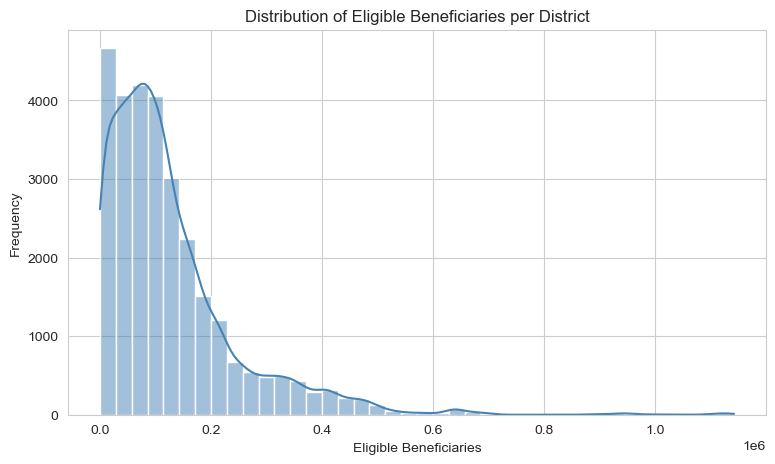

In [ ]:
#1.
plt.figure(figsize=(9, 5))
sns.histplot(df['eligible_beneficiaries'].dropna(), bins=40, kde=True, color='steelblue')
plt.title('Distribution of Eligible Beneficiaries per District')
plt.xlabel('Eligible Beneficiaries')
plt.ylabel('Frequency')
plt.show()

**Interpretation of your above chart**

The distribution is right-skewed — most districts have a moderate beneficiary count, but a small number of districts report very high beneficiary numbers, stretching the tail of the distribution. The feature used is `eligible_beneficiaries`, a single numeric column. This shows that beneficiary load is not evenly spread across districts, which matters for how staffing and infrastructure should be allocated.

#### Spread of Anganwadi Centres per District

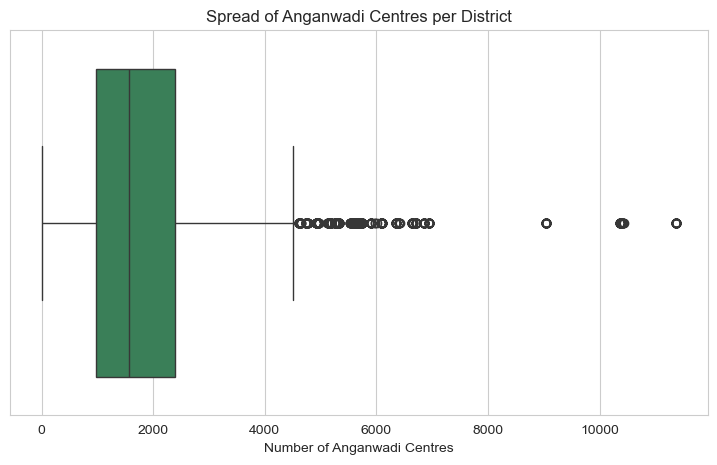

In [ ]:
#2.
plt.figure(figsize=(9, 5))
sns.boxplot(x=df['anganwadi_centers'].dropna(), color='seagreen')
plt.title('Spread of Anganwadi Centres per District')
plt.xlabel('Number of Anganwadi Centres')
plt.show()

Interpretation

The boxplot shows a compact interquartile range with a long right tail of outlier districts that have far more centres than typical. These outliers are likely large or densely populated districts and are worth keeping in mind when comparing district averages rather than totals.

#### Distribution of Underweight Children (%)

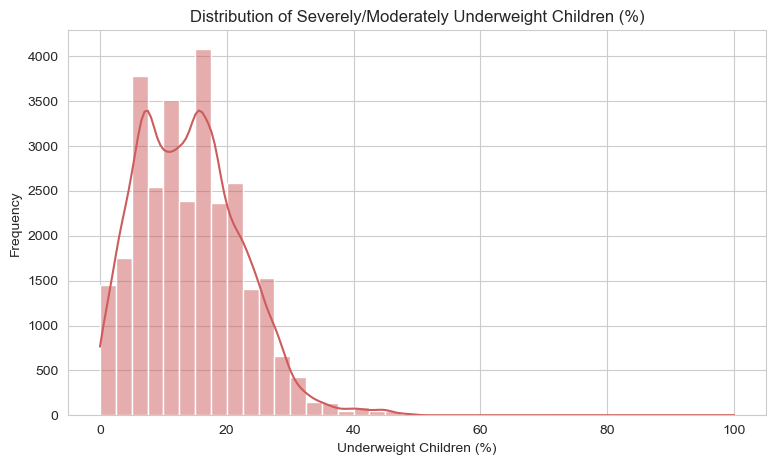

In [ ]:
#3.
plt.figure(figsize=(9, 5))
sns.histplot(df['severely_moderately_underweight'].dropna(), bins=40, kde=True, color='indianred')
plt.title('Distribution of Severely/Moderately Underweight Children (%)')
plt.xlabel('Underweight Children (%)')
plt.ylabel('Frequency')
plt.show()

Interpretation

Most districts report a relatively low percentage of underweight children, but there is a visible right tail, consistent with the high skewness seen in the statistical analysis — a subset of districts carries a disproportionately high nutritional burden.

#2. Bivariate Analysis (3- 4 Visuals)

#### Anganwadi Workers vs. Eligible Beneficiaries

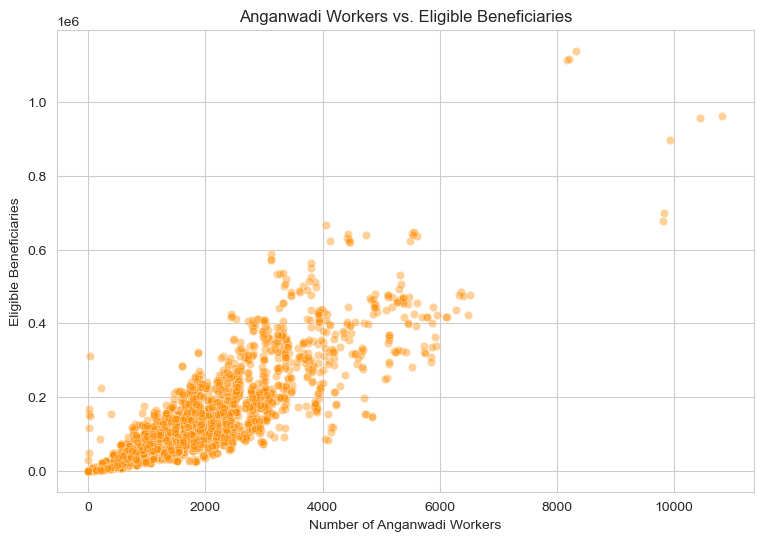

In [ ]:
#1 .
sample = df[['anganwadi_workers', 'eligible_beneficiaries']].dropna().sample(3000, random_state=42)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=sample, x='anganwadi_workers', y='eligible_beneficiaries', alpha=0.4, color='darkorange')
plt.title('Anganwadi Workers vs. Eligible Beneficiaries')
plt.xlabel('Number of Anganwadi Workers')
plt.ylabel('Eligible Beneficiaries')
plt.show()

Interpretation

There is a positive relationship between the number of workers and beneficiaries, which is expected, but the spread is wide — some districts have relatively few workers for a large beneficiary base, which points to workforce strain in those specific areas rather than the norm.

#### Aadhaar Coverage Rate by Top 10 States

C:\Users\Admin\AppData\Local\Temp\ipykernel_11900\931298873.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g['aadhar_verified_beneficiaries'].sum() / g['eligible_beneficiaries'].sum())


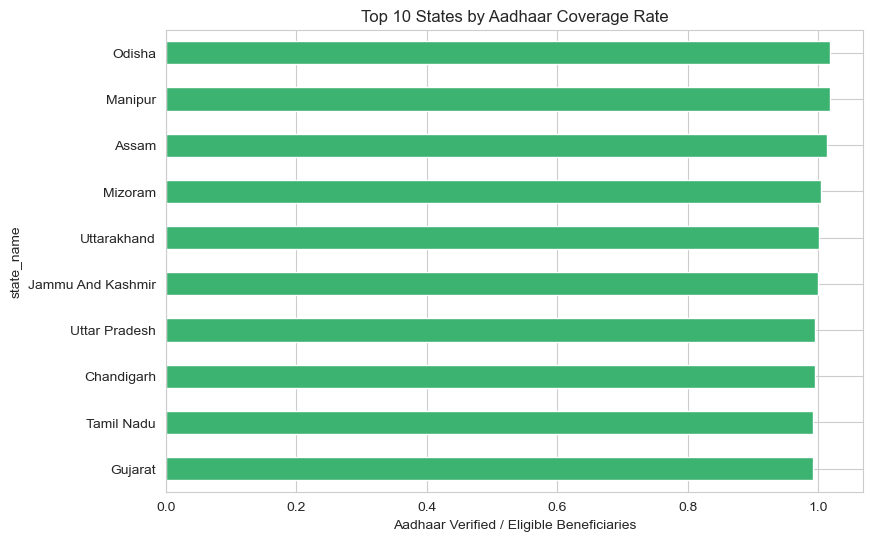

In [ ]:
#2 .
state_coverage = (
    df.groupby('state_name')
    .apply(lambda g: g['aadhar_verified_beneficiaries'].sum() / g['eligible_beneficiaries'].sum())
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 6))
state_coverage.plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 States by Aadhaar Coverage Rate')
plt.xlabel('Aadhaar Verified / Eligible Beneficiaries')
plt.gca().invert_yaxis()
plt.show()

Interpretation

A handful of states report near-complete Aadhaar verification, showing that high coverage is achievable at scale. This makes the states missing from this top-10 list useful targets for comparison in future coverage-improvement planning.

#3. Multivariate Analysis (2-3 Visuals)

#### Correlation Among Infrastructure, Workforce, and Malnutrition Indicators

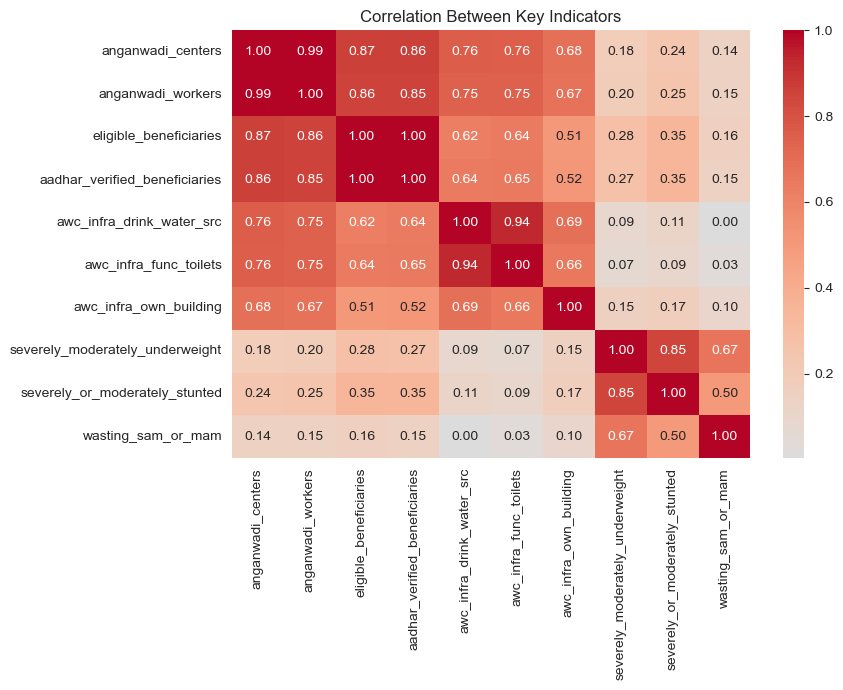

In [ ]:
#1 .
plt.figure(figsize=(9, 7))
sns.heatmap(df[key_vars].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Key Indicators')
plt.tight_layout()
plt.show()

Interpretation

The three malnutrition indicators are strongly correlated with each other, which is expected since they measure related aspects of child nutrition. Infrastructure and workforce variables correlate strongly with each other too (larger districts have more of both), but show a much weaker relationship with the malnutrition indicators — suggesting malnutrition levels are driven by more than just infrastructure and staffing counts alone.

#### Malnutrition Indicators Across the Top States by Anganwadi Centre Count

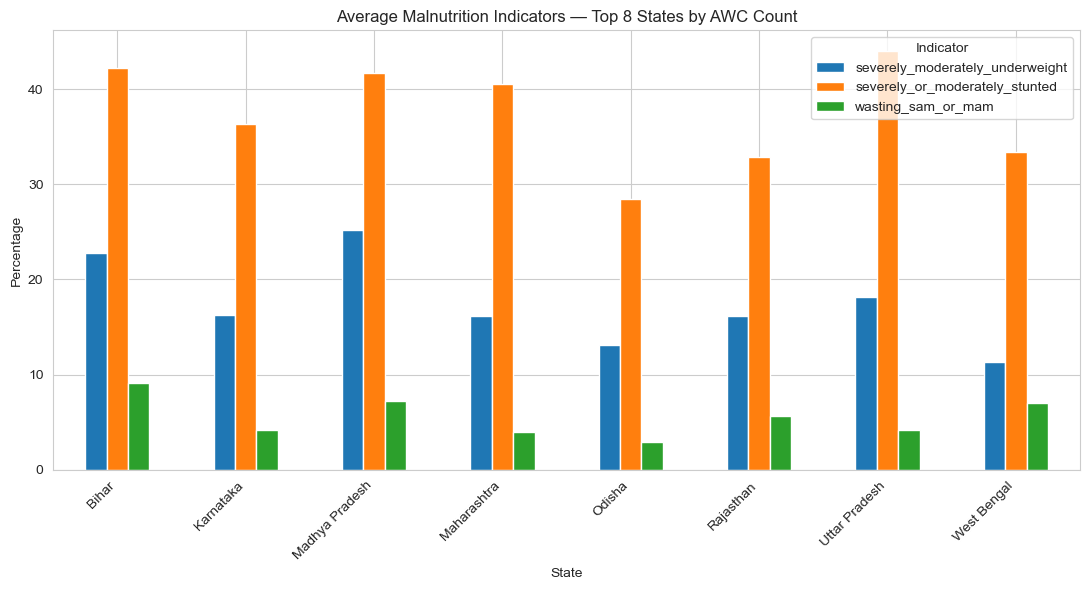

In [ ]:
#2 .
top_states = df.groupby('state_name')['anganwadi_centers'].sum().sort_values(ascending=False).head(8).index

malnutrition_by_state = (
    df[df['state_name'].isin(top_states)]
    .groupby('state_name')[['severely_moderately_underweight', 'severely_or_moderately_stunted', 'wasting_sam_or_mam']]
    .mean()
)

malnutrition_by_state.plot(kind='bar', figsize=(11, 6))
plt.title('Average Malnutrition Indicators — Top 8 States by AWC Count')
plt.ylabel('Percentage')
plt.xlabel('State')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Indicator')
plt.tight_layout()
plt.show()

Interpretation

Even among the largest states by Anganwadi Centre count, malnutrition levels vary noticeably — some states combine a large AWC network with comparatively low malnutrition indicators, while others show higher rates despite similar infrastructure scale. This reinforces that centre count alone does not determine nutritional outcomes.

# **Stage 4**


# **Documentation, Insights & Presentation**

**Summary of Findings (Plain English)**

Anganwadi infrastructure, workforce, beneficiary load, and child malnutrition all vary widely from district to district rather than being evenly spread across India. Districts with more Anganwadi Centres tend to have more workers and beneficiaries as well, but that scale does not automatically translate into lower malnutrition rates — some large-network states still show comparatively high underweight, stunting, and wasting figures. Aadhaar verification coverage is also uneven: a small group of states have nearly complete verification while others lag well behind.

**Key Insights (3–5)**

1. Beneficiary load and centre counts are both heavily right-skewed — a minority of districts carry a disproportionately large share of beneficiaries and centres, so national averages understate the pressure on these high-load districts.
2. Worker availability rises with beneficiary count but not proportionally everywhere; some districts show visible workforce strain (many beneficiaries per worker).
3. Malnutrition indicators (underweight, stunting, wasting) are strongly correlated with each other but only weakly correlated with infrastructure and workforce counts, indicating malnutrition is driven by factors beyond AWC scale alone (e.g., health-seeking behaviour, sanitation, maternal health, food security).
4. Aadhaar coverage is achievable at near-100% in the top-performing states, showing the gap in lagging states is an execution problem rather than a structural limitation.
5. Large-network states (top 8 by AWC count) still show meaningful variation in malnutrition outcomes, confirming that infrastructure quantity is not a substitute for infrastructure quality or service delivery effectiveness.

**Types of Analysis**

Descriptive Analysis — Central tendency, spread, skewness/kurtosis, and univariate/bivariate/multivariate visualizations were used to describe how AWC infrastructure, workforce, beneficiary coverage, and malnutrition indicators are currently distributed across districts and states.

Diagnostic Analysis — The correlation heatmap and the workers-vs-beneficiaries scatterplot were used to explore *why* certain districts show workforce strain or elevated malnutrition, by relating outcome variables to infrastructure and staffing variables.

Predictive Analysis — Not built in this stage. A natural next step would be a regression or classification model that predicts a district's malnutrition risk level from its infrastructure, workforce, and coverage features.

Prescriptive Analysis — Not built in this stage. Once a predictive model exists, it could be paired with optimization logic to recommend where additional workers, infrastructure investment, or Aadhaar verification drives would have the largest impact per rupee spent.

**Recommendations / Decision Support**

- Prioritize workforce reinforcement in districts with a high beneficiaries-per-worker ratio rather than distributing new hires evenly.
- Study the practices of top-performing states on Aadhaar coverage and infrastructure availability, and use them as a playbook for lagging states.
- Since infrastructure/workforce scale alone doesn't explain malnutrition, pair AWC investment with complementary levers (maternal health outreach, food security programs) in high-burden districts.
- Treat the identified outlier districts (very high beneficiary counts or centre counts) as a distinct planning tier rather than folding them into national or state averages.

# **Future Enhancement**

Use a larger or more recent Poshan Tracker snapshot for deeper, more current insights

Automate parts of the analysis with scripts or a refreshable dashboard (e.g., Power BI/Tableau) so state and district officials can self-serve these views

Extend the analysis to predictive modeling — e.g., a regression/classification model to flag districts at high risk of malnutrition escalation, so intervention can be prioritized before conditions worsen